# Filtri

## Filtriranje z FIR

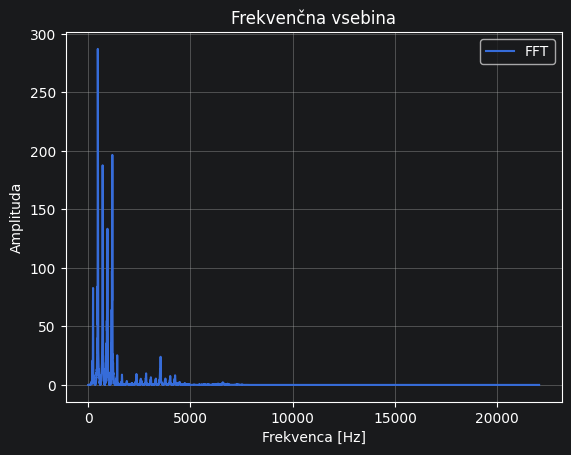

Frequencies to filter: [ 237.33692119  705.34399613  941.34756383 1180.01783852 1418.6881132 ]


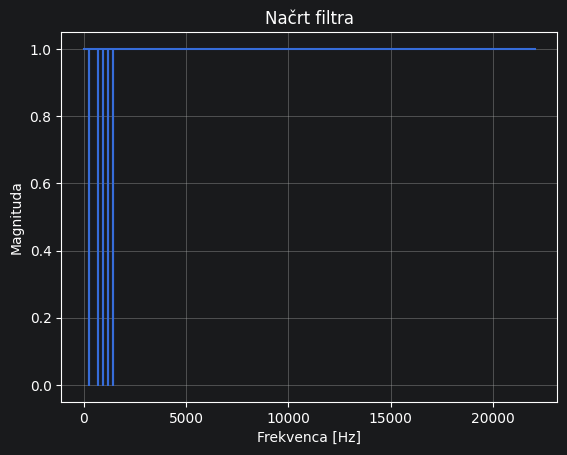

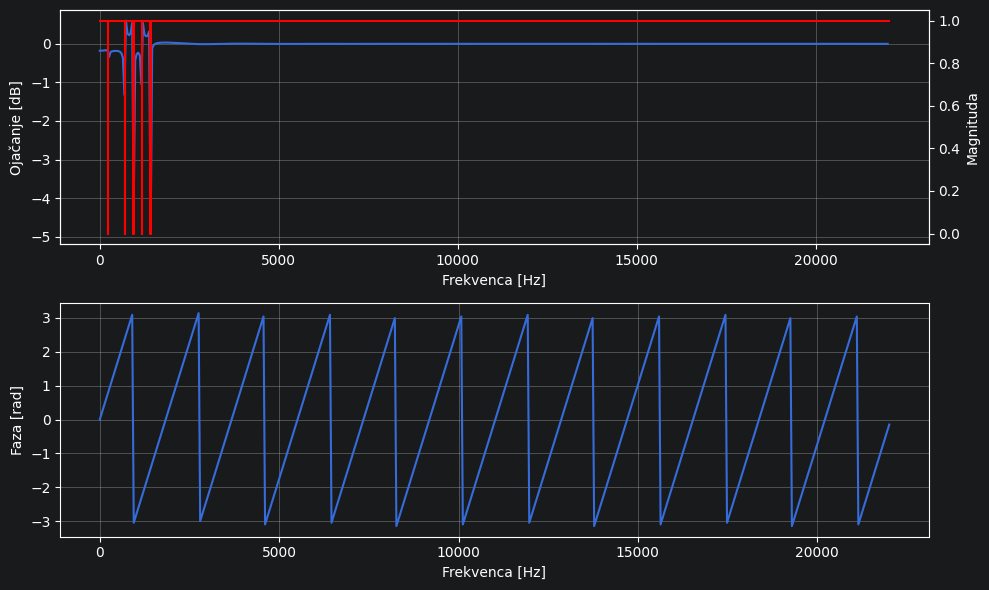

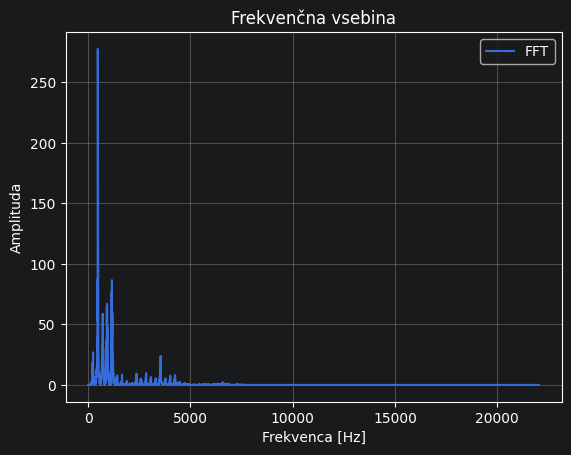

In [128]:
import util, filter
from importlib import reload

reload(util)
reload(filter)

import os
from filter import *
from util import *


file_name = "a_high_pitch.mp3"
fo = 2001

y, Fs = read_signal_from_mp3(fr"recordings/{file_name}")

y_fft = np.fft.fft(y)
plot_fft(y_fft, Fs)

harmonics = find_harmonics(y_fft, Fs, prominence=(50, None), distance=150)

y_fil = design_fir(y, harmonics, Fs, fo, plot=True)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs)


## Filtriranje s IIR

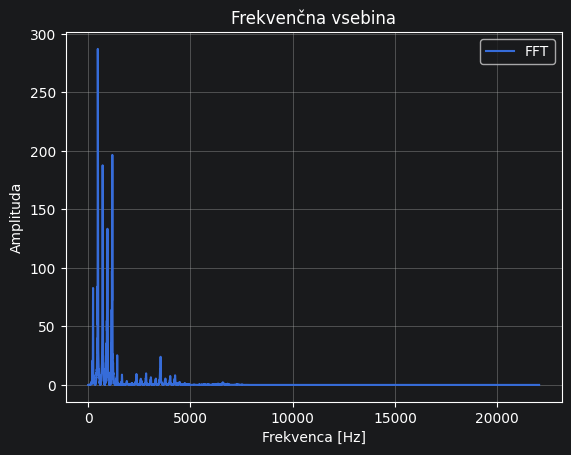

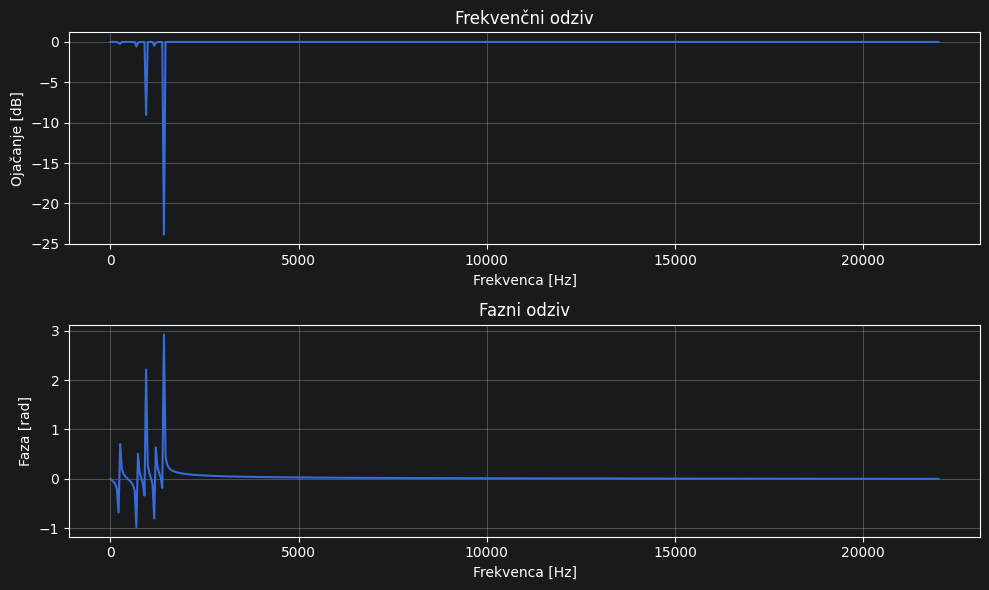

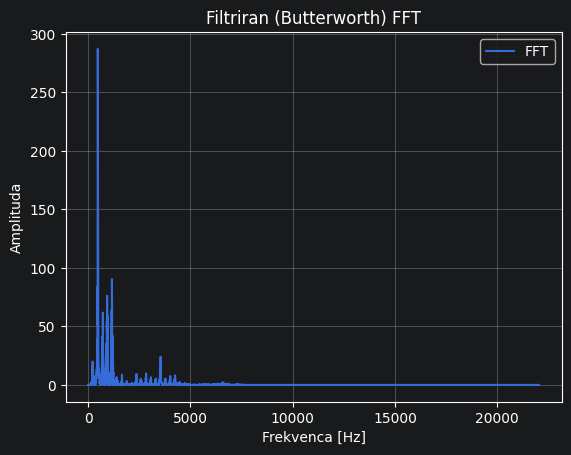

In [129]:
file_name = "a_high_pitch.mp3"
y, Fs = read_signal_from_mp3(fr"recordings/{file_name}")

y_fft = np.fft.fft(y)
plot_fft(y_fft, Fs)

harmonics= find_harmonics(y_fft, Fs, prominence=(50, None), distance=150)

# Butterworth
fo = 2
y_fil = design_iir(y, harmonics, Fs, fo, plot=True)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs, label="Filtriran (Butterworth) FFT")

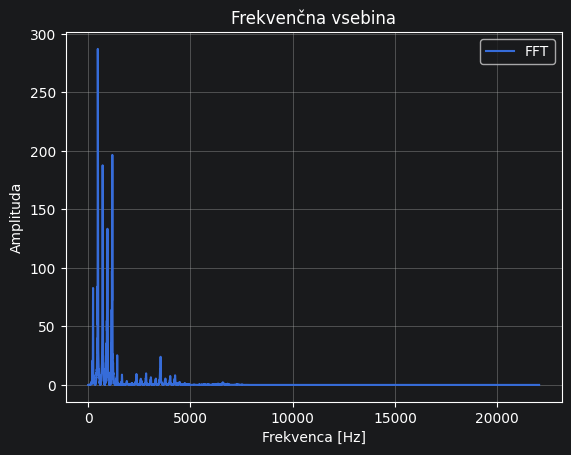

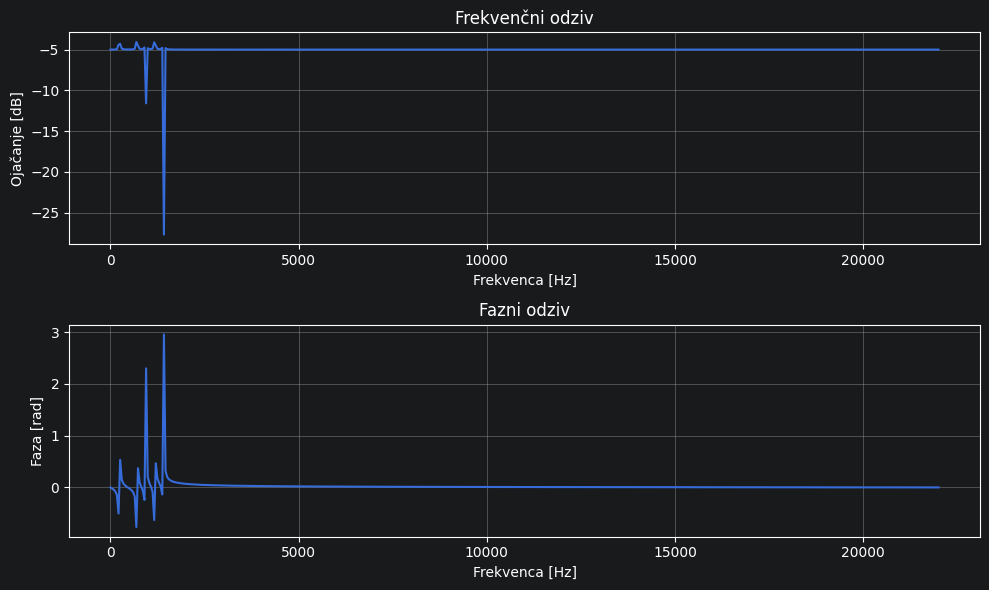

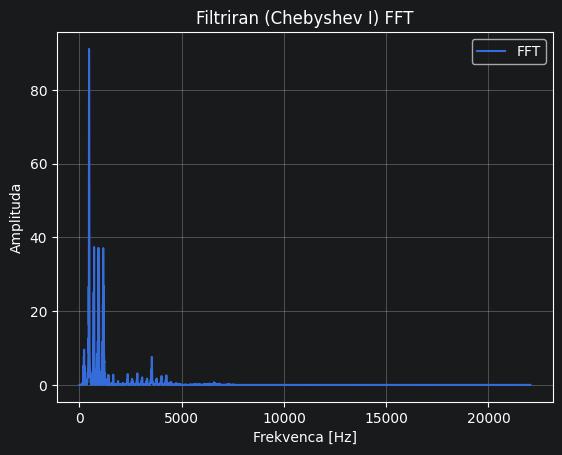

In [130]:
# Chebyshev I
plot_fft(y_fft, Fs)
y_fil = design_iir(y, harmonics, Fs, fo, filter_type=Filter.CHEBYSHEV_I, plot=True)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs, label="Filtriran (Chebyshev I) FFT")

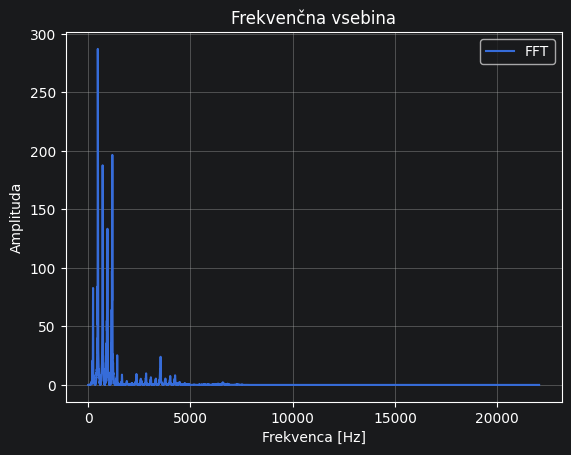

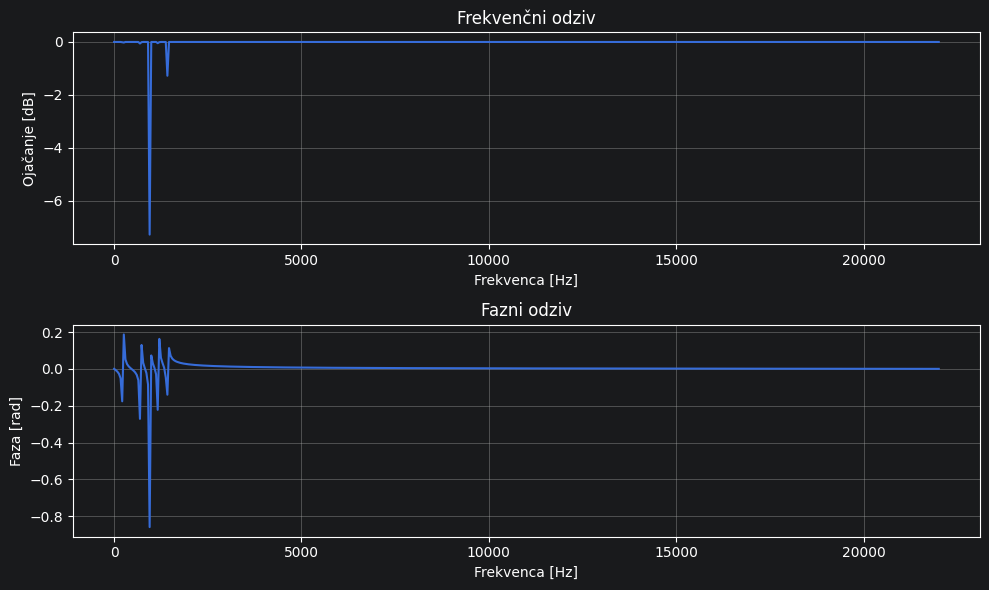

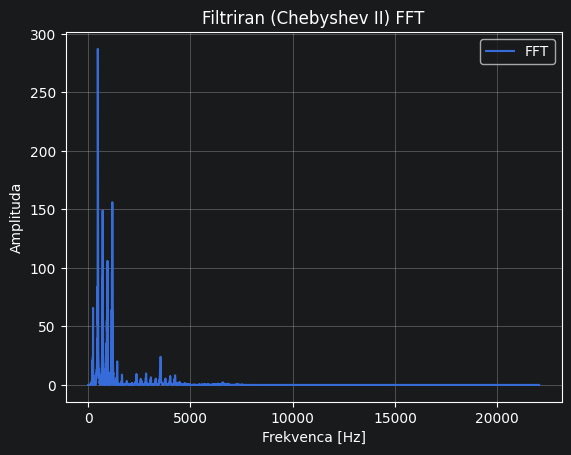

In [131]:
# Chebyshev II
plot_fft(y_fft, Fs)
y_fil = design_iir(y, harmonics, Fs, fo, filter_type=Filter.CHEBYSHEV_II, plot=True)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs, label="Filtriran (Chebyshev II) FFT")

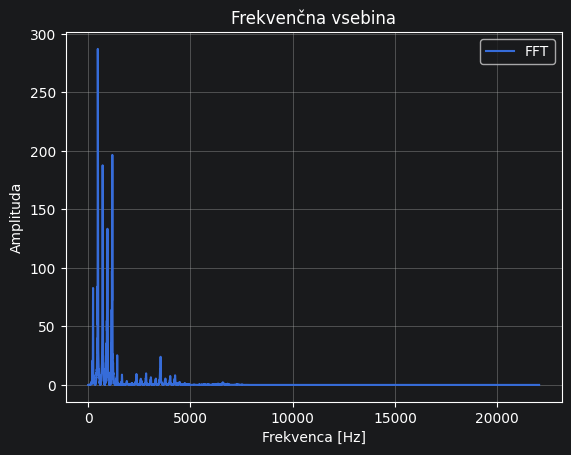

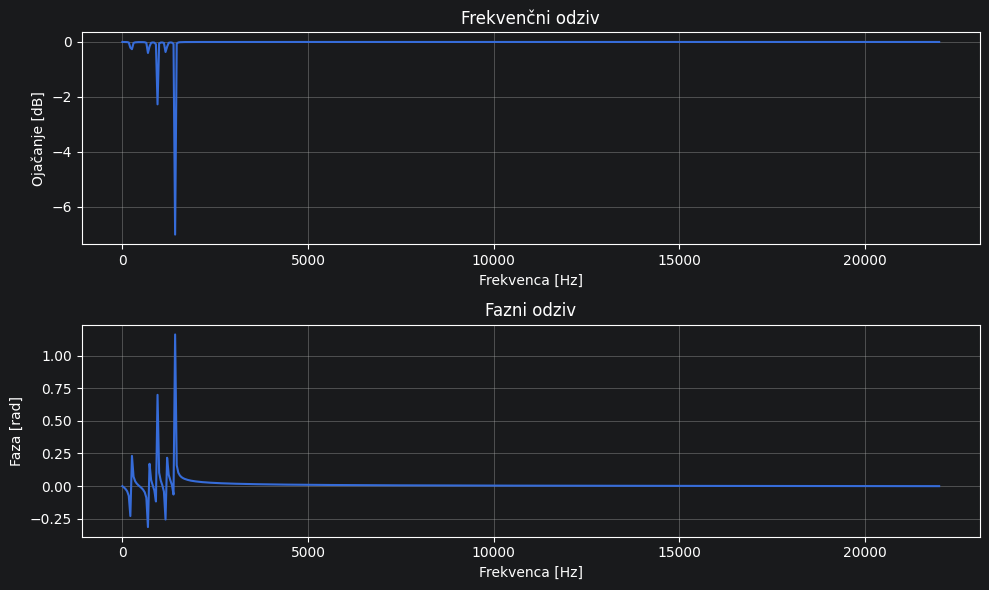

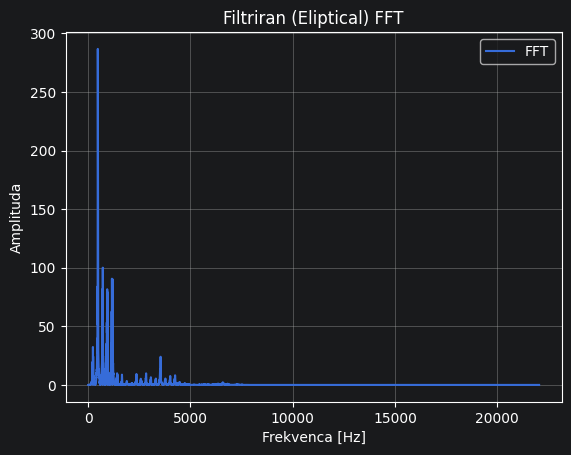

In [135]:
# Eliptical
plot_fft(y_fft, Fs)
y_fil = design_iir(y, harmonics, Fs, fo, filter_type=Filter.ELIPTICAL, plot=True)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs, label="Filtriran (Eliptical) FFT")

## Odgovori na vprašanja

### Kako je frekvenčna učinkovitost filtra odvisna od reda filtra (t.j. od števila koeficientov a in b)?

O: Iz spodnjih primerov lahko nasledenje:
1. FIR Filtri:
- nižji red -> počasnejše zapiranje/odpiranje filtra in več rippla
- višji red ->bolj ostro zapiranje/odpiranje filtra, in manj rippla

2. IIR Filtri:
- višji red -> globoke zareze v frekvnečnem odzivu
- nižji red -> plitke zareze v frekvenčnem odzivu

**FIR filtriranje**

In [ ]:
y, Fs = read_signal_from_mp3(fr"recordings/a_high_pitch.mp3")

y_fft = np.fft.fft(y)
plot_fft(y_fft, Fs)

harmonics = find_harmonics(y_fft, Fs, prominence=(50, None), distance=150)

# FIR - primerjava redov
fir_orders = [101, 501, 2001, 8001]
for fo in fir_orders:
    print(f"Red filtra: {fo}")
    y_fil = design_fir(y, harmonics, Fs, fo, plot=True)
    y_fil_fft = np.fft.fft(y_fil)
    plot_fft(y_fil_fft, Fs)

**IIR Filtriranje**

In [ ]:
# IIR - primerjava redov
iir_orders = [2, 4, 6, 8]
for fo in iir_orders:
    print(f"Red filtra: {fo}")
    plot_fft(y_fft, Fs)
    y_fil = design_iir(y, harmonics, Fs, fo, filter_type=Filter.CHEBYSHEV_II, plot=True)
    y_fil_fft = np.fft.fft(y_fil)
    plot_fft(y_fil_fft, Fs, label=f"Filtriran (Chebyshev II) FFT")

### Kako lahko višje harmonike odstranimo s kaskado filtrov in kaj s tem pridobimo v primerjavi z uporabo enega samega filtra?

O: Višje harmonike odstranimo s kaskado tako, da za vsak harmonik
načrtamo ločen filter nizkega reda, ki ga zaporedno apliciramo na signal. Z tem pristopom pridobimo na numerični stabilnosti filtra, saj imamo več filtrov nižjega reda kar je prednost saj previsoki redo pripeljejo do nestabilnosti filtra (poli izven enotske krožnice).

Primeri kaskadnega filtriranja so prisotni v vipje v poročilu.

### Kako je frekvenčna učinkovitost kaskade filtrov primerljiva s filtriranjem v frekvenčnem prostoru?

O: Filtriranje v frekvenčnem prostoru je teoretično idealno, zareze so popolnoma ostre brez ripple in faznega popačenja, vendar zahteva cel signal vnaprej kar ga naredi neprimernega za realnočasovno obdelavo. Kaskada filtrov ima končno prehodno območje in fazno popačenje, vendar deluje vzorec po vzorec in je zato praktičnejša za realnočasovno uporabo.

## Filtriranje vseh posnetkov iz naloge 1

In [ ]:
FILES = os.listdir("recordings")

for file in FILES:
    y, Fs = read_signal_from_mp3(fr"recordings/{file}")
    y_fil = design_fir(y, harmonics, Fs, fo, plot=True)
    y_fil_fft = np.fft.fft(y_fil)
    plot_fft(y_fil_fft, Fs,  label=f"Filtriran {file} (FIR načrtovanje) FFT")

    for filter in Filter:
        plot_fft(y_fft, Fs, label=f"Frekvenčna vsebina {file}")
        y_fil = design_iir(y, harmonics, Fs, fo, filter_type=filter, plot=True)
        y_fil_fft = np.fft.fft(y_fil)
        plot_fft(y_fil_fft, Fs, label=f"Filtriran {file} (IIR - {filter}) FFT")
